In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
np.random.seed(42)
epsilon = np.random.normal(0, 0.5, 1000)
X = np.random.rand(1000, 2)
y = 3 * X[:, 0] + 5 * X[:, 1] + 3 + epsilon
X_with_bias = np.c_[np.ones(X.shape[0]), X]

In [13]:
eta = 0.1
n_epochs = 500
theta = np.zeros(X_with_bias.shape[1])

theta_values = []

for epoch in range(n_epochs):
    y_pred = X_with_bias @ theta
    error = y_pred - y
    gradients = 2 / X.shape[0] * X_with_bias.T @ error
    theta -= eta * gradients

    if epoch % 5 == 0:
        theta_values.append(theta.copy())


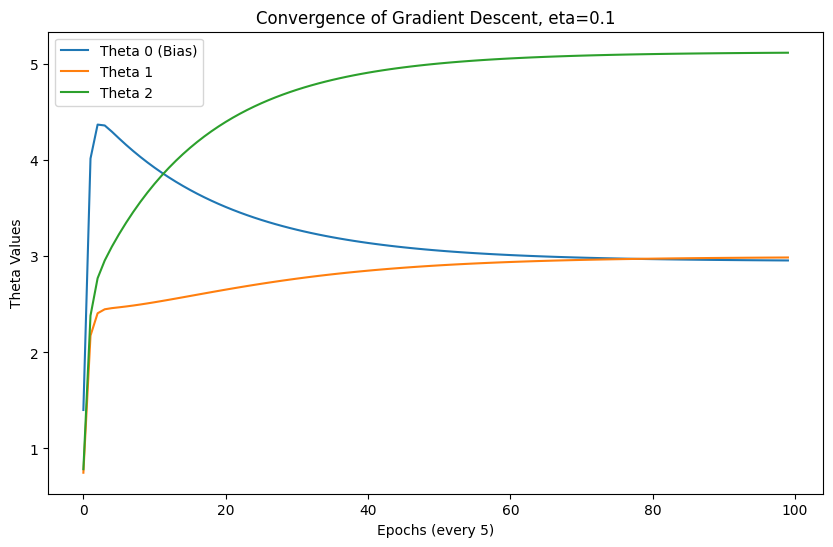

In [14]:
theta_values = np.array(theta_values)
epochs=np.arange(len(theta_values))

plt.figure(figsize=(10, 6))
plt.plot(epochs, theta_values, label=['Theta 0 (Bias)', 'Theta 1', 'Theta 2'])
plt.xlabel('Epochs (every 5)')
plt.ylabel('Theta Values')
plt.title('Convergence of Gradient Descent, eta=0.1')
plt.legend()
plt.show()

In [15]:
eta = 0.01
n_epochs = 5000
theta = np.zeros(X_with_bias.shape[1])

theta_values_20 = []

for epoch in range(n_epochs):
    y_pred = X_with_bias @ theta
    error = y_pred - y
    gradients = 2 / X.shape[0] * X_with_bias.T @ error
    theta -= eta * gradients

    if epoch % 20 == 0:
        theta_values_20.append(theta.copy())

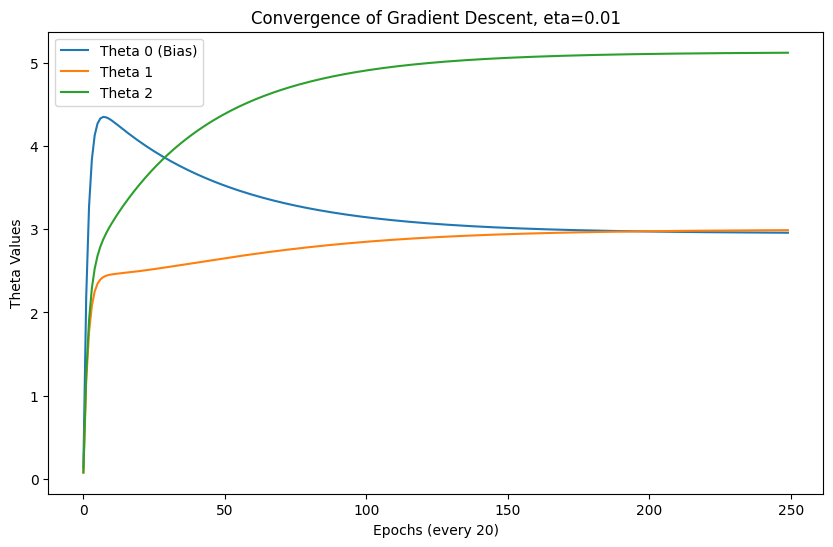

In [16]:
theta_values_20 = np.array(theta_values_20)
epochs=np.arange(len(theta_values_20))

plt.figure(figsize=(10, 6))
plt.plot(epochs, theta_values_20[:, 0], label='Theta 0 (Bias)')
plt.plot(epochs, theta_values_20[:, 1], label='Theta 1')
plt.plot(epochs, theta_values_20[:, 2], label='Theta 2')
plt.xlabel('Epochs (every 20)')
plt.ylabel('Theta Values')
plt.title('Convergence of Gradient Descent, eta=0.01')
plt.legend()
plt.show()

In [17]:
eta = 0.1
n_epochs = 500
theta = np.zeros(X_with_bias.shape[1])
m = X_with_bias.shape[0]

theta_values_sgd = []

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_with_bias[random_index:random_index+1]
        yi = y[random_index:random_index+1]

        y_pred = xi @ theta
        error = y_pred - yi
        gradients = 2 * xi.T @ error
        theta -= eta * gradients

        if epoch % 5 == 0:
            theta_values_sgd.append(theta.copy())


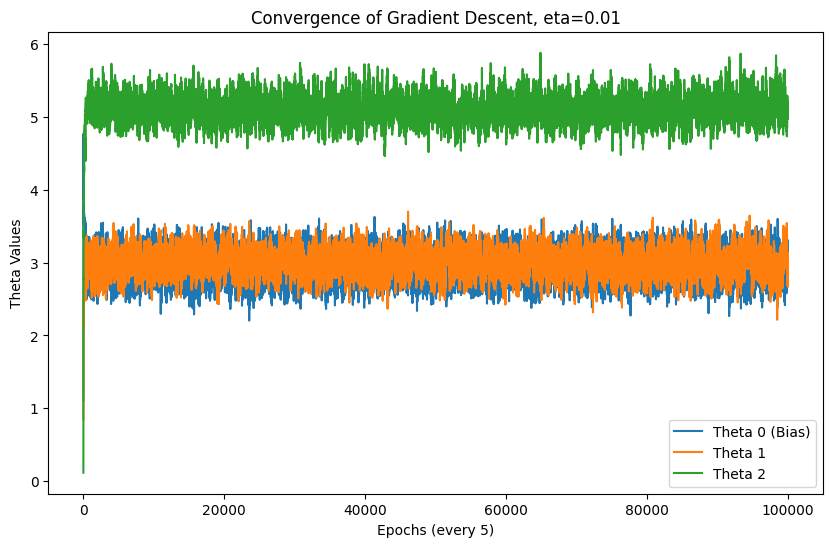

In [18]:
theta_values_sgd = np.array(theta_values_sgd)
epochs=np.arange(len(theta_values_sgd))

plt.figure(figsize=(10, 6))
plt.plot(epochs, theta_values_sgd[:, 0], label='Theta 0 (Bias)')
plt.plot(epochs, theta_values_sgd[:, 1], label='Theta 1')
plt.plot(epochs, theta_values_sgd[:, 2], label='Theta 2')
plt.xlabel('Epochs (every 5)')
plt.ylabel('Theta Values')
plt.title('Convergence of Gradient Descent, eta=0.01')
plt.legend()
plt.show()

In [19]:
eta = 0.01
n_epochs = 500
theta = np.zeros(X_with_bias.shape[1])
m = X_with_bias.shape[0]

theta_values_sgd_20 = []

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_with_bias[random_index:random_index+1]
        yi = y[random_index:random_index+1]

        y_pred = xi @ theta
        error = y_pred - yi
        gradients = 2 * xi.T @ error
        theta -= eta * gradients

        if epoch % 20 == 0:
            theta_values_sgd_20.append(theta.copy())

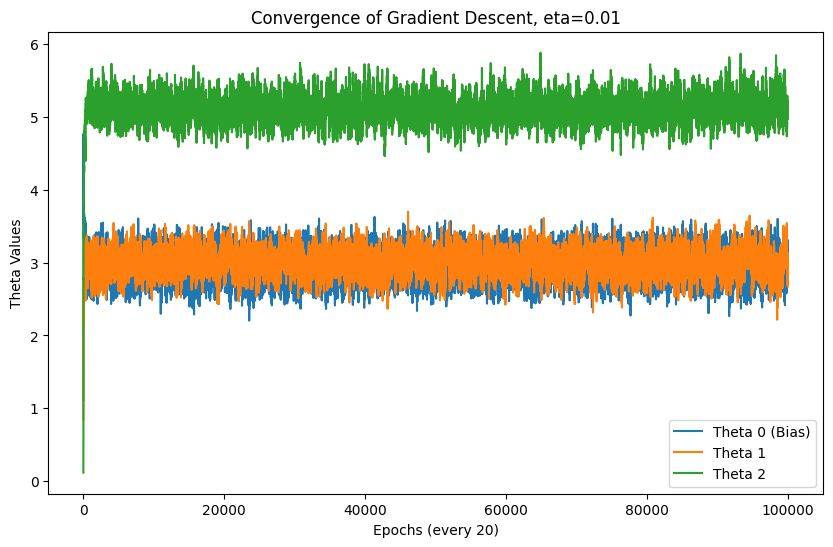

In [20]:
theta_values_sgd_20 = np.array(theta_values_sgd)
epochs=np.arange(len(theta_values_sgd_20))

plt.figure(figsize=(10, 6))
plt.plot(epochs, theta_values_sgd[:, 0], label='Theta 0 (Bias)')
plt.plot(epochs, theta_values_sgd[:, 1], label='Theta 1')
plt.plot(epochs, theta_values_sgd[:, 2], label='Theta 2')
plt.xlabel('Epochs (every 20)')
plt.ylabel('Theta Values')
plt.title('Convergence of Gradient Descent, eta=0.01')
plt.legend()
plt.show()

In [32]:
eta = 0.1
n_epochs = 500
batch_sizes = [5, 10, 20, 50, 100]
theta = np.zeros(X_with_bias.shape[1])
m = X_with_bias.shape[0]

all_theta_history= {}

for batch_size in batch_sizes:
    theta_values_mbgd = []

    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        X_shuffled = X_with_bias[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            y_pred = X_batch @ theta
            gradients = (2 / len(X_batch)) * X_batch.T @ (y_pred - y_batch)

            theta -= eta * gradients

            if epoch % 5 == 0:
                theta_values_mbgd.append(theta.copy())
    all_theta_history[batch_size] = theta_values_mbgd

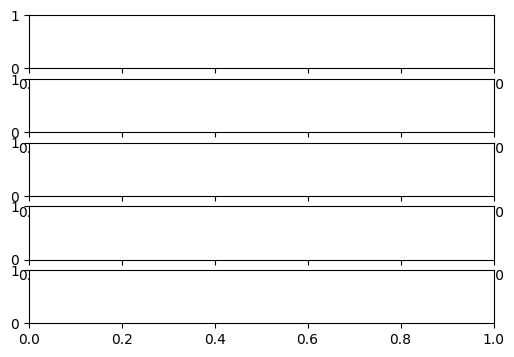

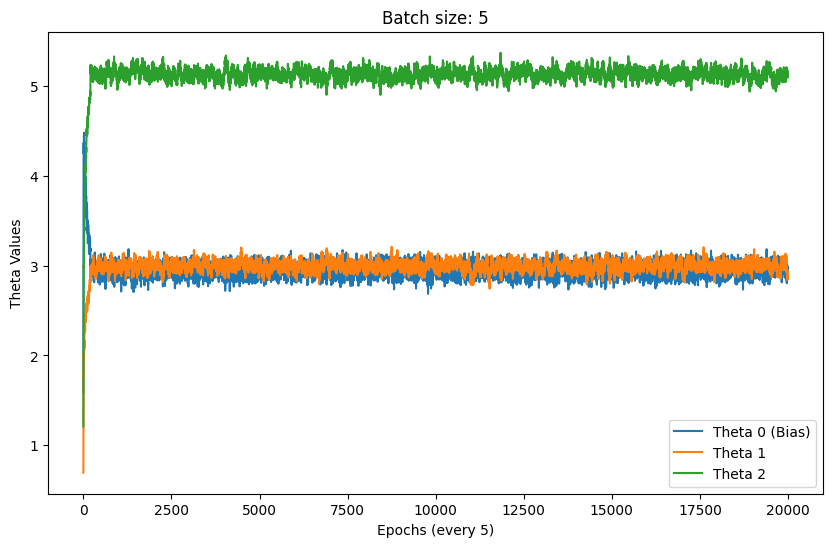

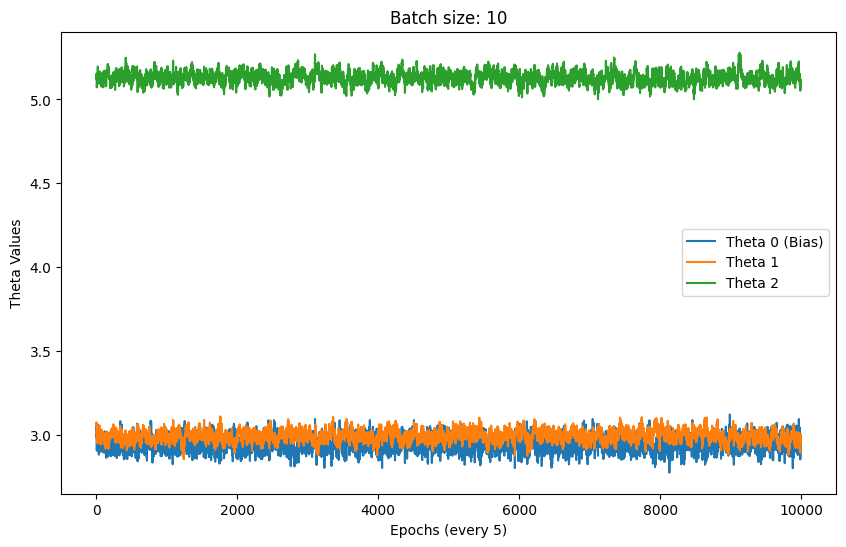

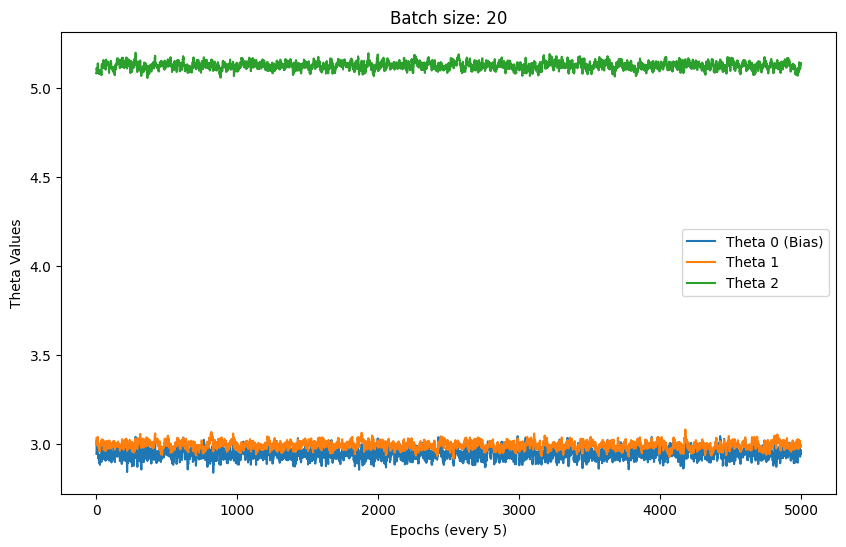

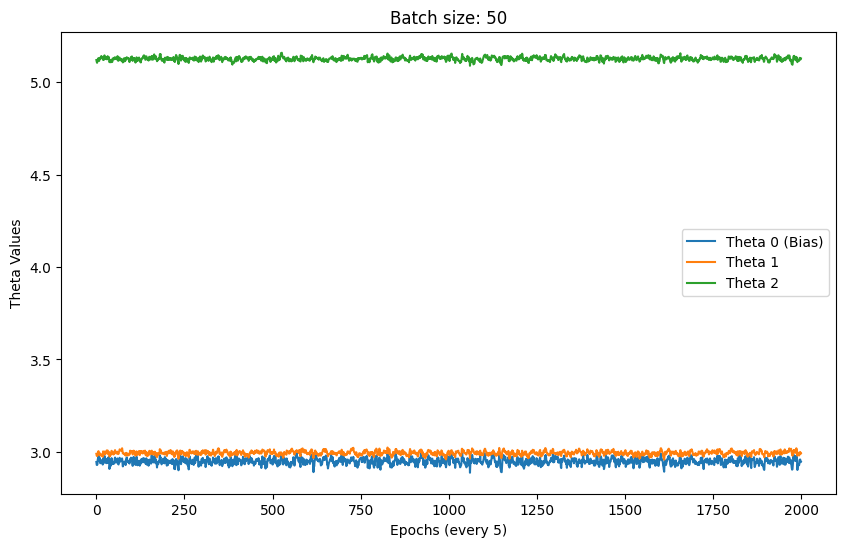

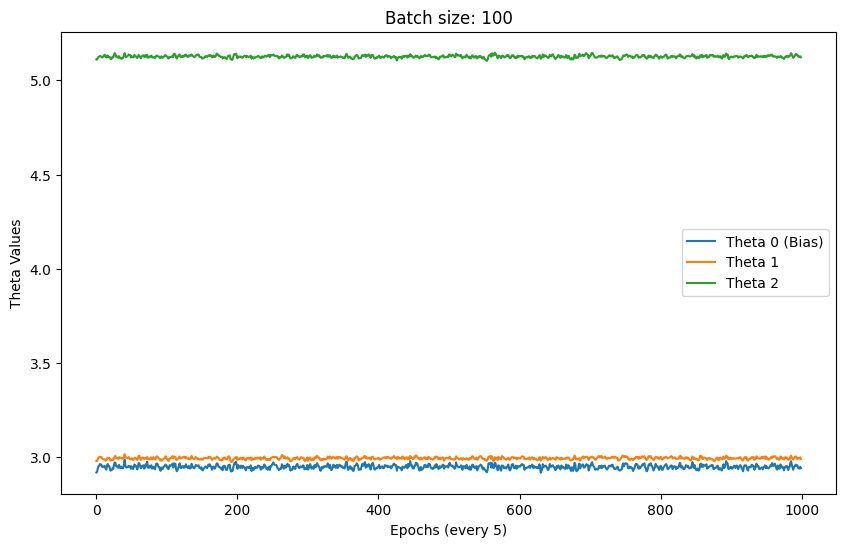

In [36]:
fig, axes = plt.subplots(5, 1, figsize= (6, 4))
axes = axes.flatten()
for idx, batch_size in enumerate(batch_sizes):

    theta_values_mbgd = all_theta_history[batch_size]
    epochs=np.arange(len(theta_values_mbgd))
    theta_values_mbgd = np.array(theta_values_mbgd)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, theta_values_mbgd[:, 0], label='Theta 0 (Bias)')
    plt.plot(epochs, theta_values_mbgd[:, 1], label='Theta 1')
    plt.plot(epochs, theta_values_mbgd[:, 2], label='Theta 2')
    plt.xlabel('Epochs (every 5)')
    plt.ylabel('Theta Values')
    plt.title(f'Batch size: {batch_size}')
    plt.legend()
plt.show()